# Regresión Logística — Guía Pedagógica Resuelta

**Dataset:** *Himalayan Climbing Expeditions* (TidyTuesday 2020-09-22) — 76,519 miembros de expediciones al Himalaya entre 1905 y 2019.

**Pregunta guía:** ¿qué factores predicen que un miembro **llegue a la cumbre** (`success`)?

---

## Hoja de ruta

1. **Motivación** — por qué la regresión lineal NO sirve para clasificar
2. **Matemática mínima** — probabilidad, odds, log-odds, sigmoide
3. **EDA** — exploración, matriz de correlación, detección de *leaks*
4. **Feature engineering** — limpieza y preparación
5. **Modelo SIMPLE (1 variable) — 3 formas de leer el resultado** ⭐ la base de toda la interpretación
6. **Matriz de confusión — celda por celda** ⭐ la base del análisis de errores
7. **Modelo MÚLTIPLE (todas las variables)** — pipeline completo
8. **Interpretación de coeficientes** en el múltiple
9. **Frontera de decisión** visualizada en 2D
10. **Métricas de ranking** — ROC-AUC, PR curve
11. **Umbral** — por qué 0.5 es una decisión, no un default
12. **Overfitting y regularización** — learning curves, L1/L2, GridSearchCV
13. **Feature selection** con Lasso
14. **Diagnóstico ético** — desempeño por subgrupo
15. **Conclusiones**


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [2]:
df = pd.read_csv('data/himalayan-members.csv')
print('Shape:', df.shape)
df.head()


Shape: (76519, 21)


,expedition_id,member_id,peak_id,peak_name,year,season,sex,age,citizenship,expedition_role,...,highpoint_metres,success,solo,oxygen_used,died,death_cause,death_height_metres,injured,injury_type,injury_height_metres
0,AMAD78301,AMAD78301-01,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Leader,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
1,AMAD78301,AMAD78301-02,AMAD,Ama Dablam,1978,Autumn,M,41.0,France,Deputy Leader,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
2,AMAD78301,AMAD78301-03,AMAD,Ama Dablam,1978,Autumn,M,27.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN
3,AMAD78301,AMAD78301-04,AMAD,Ama Dablam,1978,Autumn,M,40.0,France,Exp Doctor,...,6000.0,False,False,False,False,NaN,NaN,False,NaN,NaN
4,AMAD78301,AMAD78301-05,AMAD,Ama Dablam,1978,Autumn,M,34.0,France,Climber,...,NaN,False,False,False,False,NaN,NaN,False,NaN,NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76519 entries, 0 to 76518
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   expedition_id         76519 non-null  object 
 1   member_id             76519 non-null  object 
 2   peak_id               76519 non-null  object 
 3   peak_name             76504 non-null  object 
 4   year                  76519 non-null  int64  
 5   season                76519 non-null  object 
 6   sex                   76517 non-null  object 
 7   age                   73022 non-null  float64
 8   citizenship           76509 non-null  object 
 9   expedition_role       76498 non-null  object 
 10  hired                 76519 non-null  bool   
 11  highpoint_metres      54686 non-null  float64
 12  success               76519 non-null  bool   
 13  solo                  76519 non-null  bool   
 14  oxygen_used           76519 non-null  bool   
 15  died               

## 2. Motivación — ¿Por qué NO regresión lineal?

Queremos predecir algo **binario**: `success ∈ {0, 1}`.

Si usamos **regresión lineal**, el modelo aprende una recta:

$$\hat{y} = \beta_0 + \beta_1 x$$

El problema: $\hat{y}$ puede dar **−0.3** o **1.7** → no son probabilidades válidas.

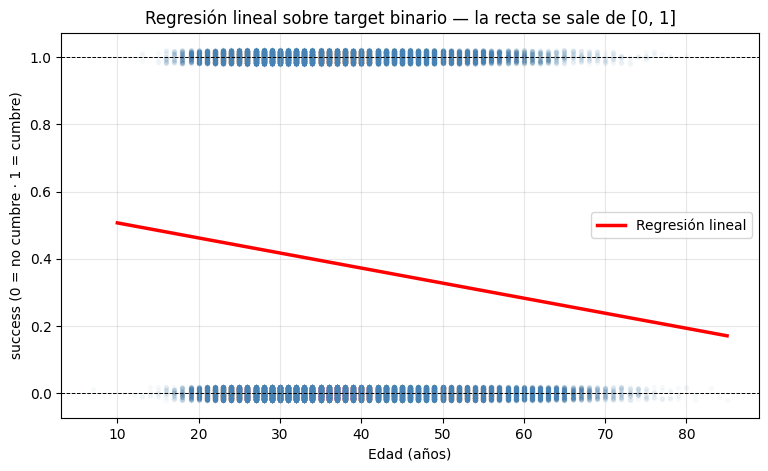

Predicción lineal en edad=15: 0.485
Predicción lineal en edad=85: 0.171


In [4]:
# Ajustamos regresion lineal usando 'age' para predecir 'success'
sub = df.dropna(subset=['age']).copy()
sub['success_int'] = sub['success'].astype(int)

X_age = sub[['age']].values
y_bin = sub['success_int'].values

lin = LinearRegression().fit(X_age, y_bin)

age_grid = np.linspace(10, 85, 200).reshape(-1, 1)
pred_lin = lin.predict(age_grid)

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(sub['age'], sub['success_int'] + np.random.uniform(-0.02, 0.02, len(sub)),
           alpha=0.03, color='steelblue', s=8)
ax.plot(age_grid, pred_lin, color='red', linewidth=2.5, label='Regresión lineal')
ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
ax.axhline(1, color='black', linestyle='--', linewidth=0.7)
ax.set_xlabel('Edad (años)')
ax.set_ylabel('success (0 = no cumbre · 1 = cumbre)')
ax.set_title('Regresión lineal sobre target binario — la recta se sale de [0, 1]')
ax.legend()
plt.show()

print(f'Predicción lineal en edad=15: {lin.predict([[15]])[0]:.3f}')
print(f'Predicción lineal en edad=85: {lin.predict([[85]])[0]:.3f}')


**Observaciones:**

- La recta predice valores fuera de $[0, 1]$ → no son probabilidades.
- El efecto de la edad es **no lineal** (subir de 20 a 25 no es lo mismo que subir de 60 a 65).
- Minimiza MSE, que no es la métrica correcta para clasificación.

**Solución:** pasar la salida lineal por una función que la aplane entre 0 y 1 → la **sigmoide**.


## 3. Matemática mínima — probabilidad, odds, log-odds

Vas a necesitar estos 3 conceptos. Los explicamos con un ejemplo concreto más abajo (sección 5), pero acá dejamos las definiciones.

### 3.1 Probabilidad
$p \in [0, 1]$. Difícil de modelar con una recta (está acotada por los extremos).

### 3.2 *Odds* (razón de momios)
$$\text{odds} = \frac{p}{1-p} \in [0, \infty)$$

Si $p = 0.75$, las odds son $0.75/0.25 = 3$ → "3 éxitos por cada fracaso".

### 3.3 *Log-odds* (logit)
$$\text{logit}(p) = \ln\!\left(\frac{p}{1-p}\right) \in (-\infty, \infty)$$

**Este sí se puede modelar con una recta.** Esa es la idea central:

$$\ln\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k$$

### 3.4 Sigmoide (inversa del logit)

Despejando $p$:

$$p = \sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k$$

La **sigmoide** toma cualquier número real y lo aplasta a $[0, 1]$ — por eso sirve como probabilidad.


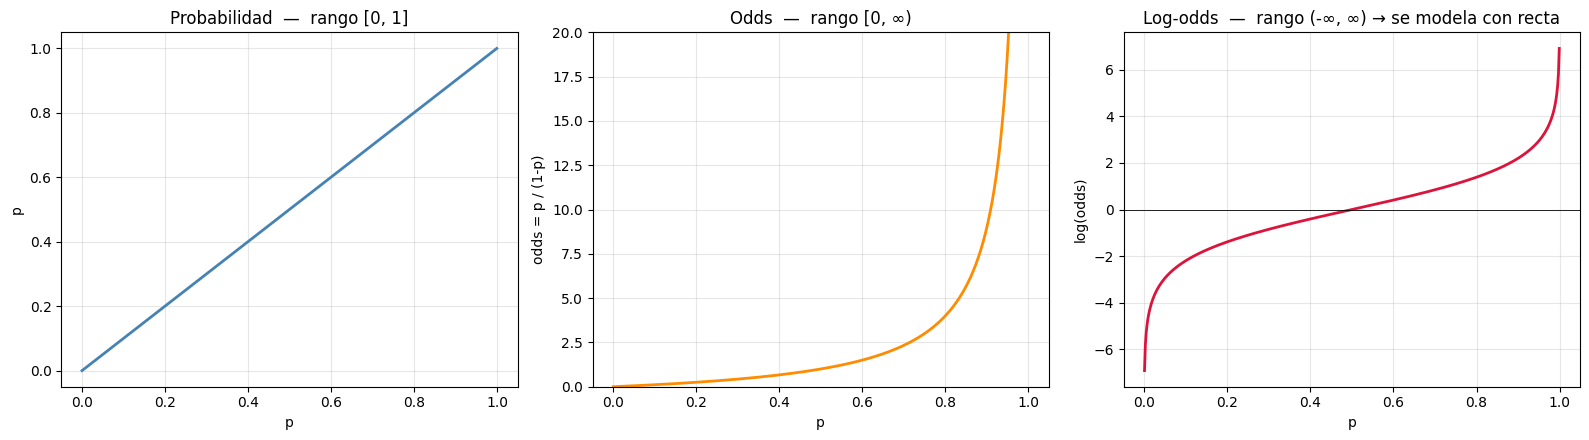

In [5]:
# Relacion entre p, odds y log-odds
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

p = np.linspace(0.001, 0.999, 500)
odds = p / (1 - p)
logodds = np.log(odds)

axes[0].plot(p, p, color='steelblue', linewidth=2)
axes[0].set_xlabel('p'); axes[0].set_ylabel('p')
axes[0].set_title('Probabilidad  —  rango [0, 1]')

axes[1].plot(p, odds, color='darkorange', linewidth=2)
axes[1].set_xlabel('p'); axes[1].set_ylabel('odds = p / (1-p)')
axes[1].set_title('Odds  —  rango [0, ∞)')
axes[1].set_ylim(0, 20)

axes[2].plot(p, logodds, color='crimson', linewidth=2)
axes[2].axhline(0, color='black', linewidth=0.6)
axes[2].set_xlabel('p'); axes[2].set_ylabel('log(odds)')
axes[2].set_title('Log-odds  —  rango (-∞, ∞) → se modela con recta')

plt.tight_layout()
plt.show()


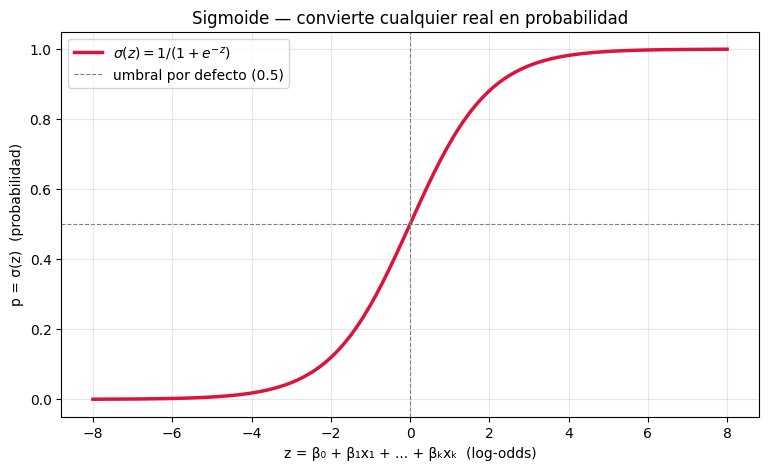

In [6]:
# La sigmoide
z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(z, sigma, color='crimson', linewidth=2.5, label=r'$\sigma(z) = 1 / (1 + e^{-z})$')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='umbral por defecto (0.5)')
ax.axvline(0,   color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('z = β₀ + β₁x₁ + ... + βₖxₖ  (log-odds)')
ax.set_ylabel('p = σ(z)  (probabilidad)')
ax.set_title('Sigmoide — convierte cualquier real en probabilidad')
ax.legend()
plt.show()


## 4. EDA — Exploración

Total miembros: 76,519
Llegaron a cumbre: 29,199 (38.2%)
No llegaron:       47,320 (61.8%)


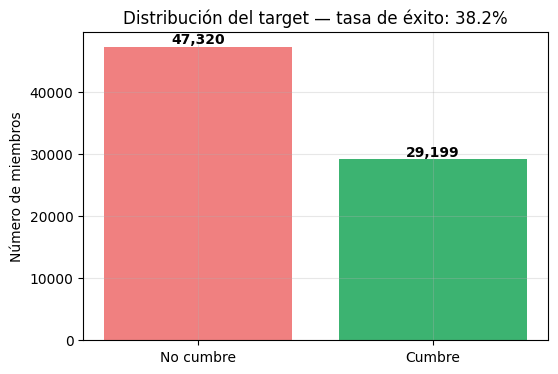

In [7]:
# Distribucion del target
counts = df['success'].value_counts()
rate = df['success'].mean()
print(f'Total miembros: {len(df):,}')
print(f'Llegaron a cumbre: {counts[True]:,} ({rate:.1%})')
print(f'No llegaron:       {counts[False]:,} ({1-rate:.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No cumbre', 'Cumbre'], counts.reindex([False, True]).values,
       color=['lightcoral', 'mediumseagreen'])
ax.set_ylabel('Número de miembros')
ax.set_title(f'Distribución del target — tasa de éxito: {rate:.1%}')
for i, v in enumerate(counts.reindex([False, True]).values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.show()


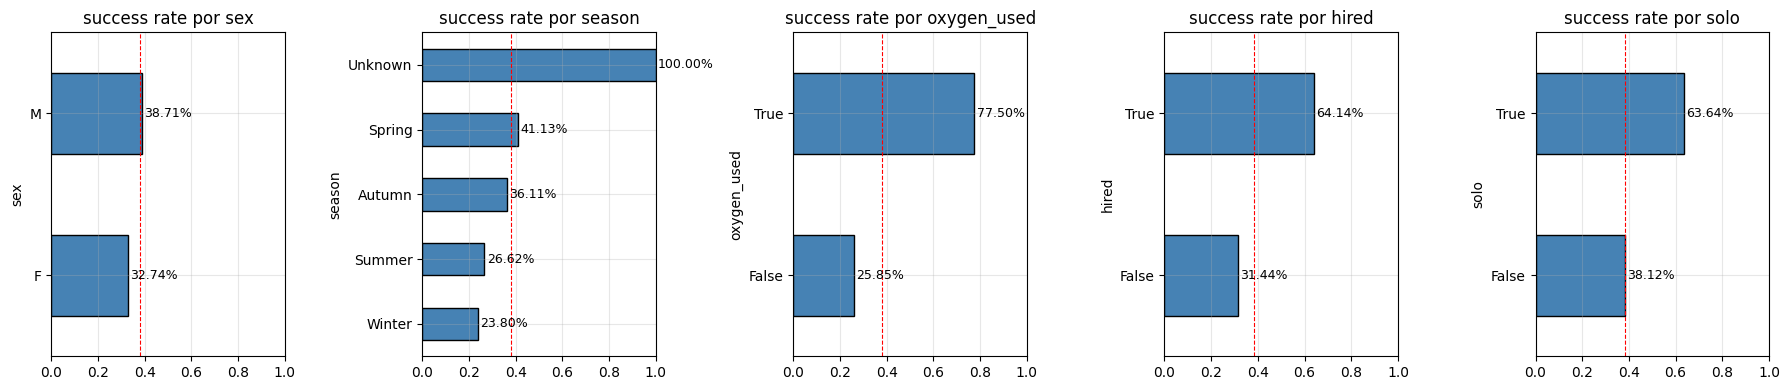

In [8]:
# Analisis univariado — success rate por cada categorica clave
cat_features_preview = ['sex', 'season', 'oxygen_used', 'hired', 'solo']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, cat_features_preview):
    rates = df.groupby(feat)['success'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'success rate por {feat}')
    ax.set_xlabel('')
    ax.axvline(df['success'].mean(), color='red', linestyle='--', linewidth=0.8, label='promedio global')
    for i, v in enumerate(rates.values):
        ax.text(v + 0.01, i, f'{v:.2%}', va='center', fontsize=9)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


**Observaciones fuertes:**

- `oxygen_used = True` → ~77% éxito vs ~26% sin oxígeno. **Va a ser el predictor más fuerte.**
- `hired = True` (sherpas contratados) → mayor éxito.
- `solo = True` → menor éxito.
- **Primavera** (marzo-mayo) es la ventana clásica del Everest.

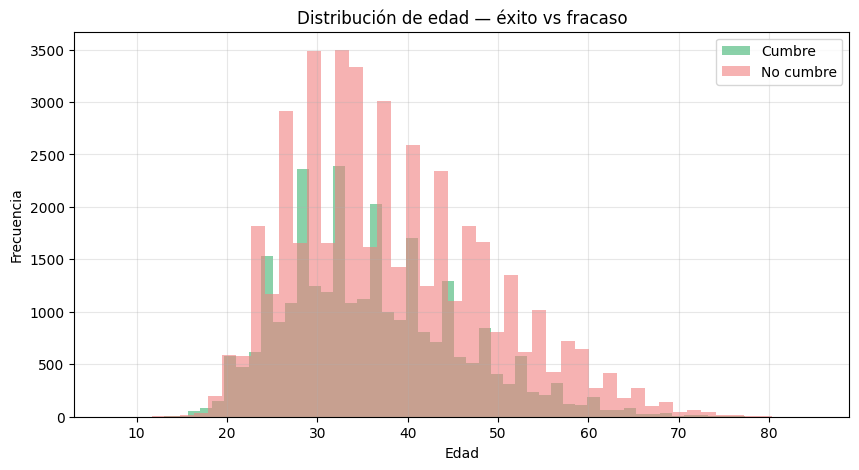

In [9]:
# Distribucion de edad por success
fig, ax = plt.subplots(figsize=(10, 5))
df[df['success'] == True]['age'].hist(bins=50, alpha=0.6, label='Cumbre', color='mediumseagreen', ax=ax)
df[df['success'] == False]['age'].hist(bins=50, alpha=0.6, label='No cumbre', color='lightcoral', ax=ax)
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de edad — éxito vs fracaso')
ax.legend()
plt.show()


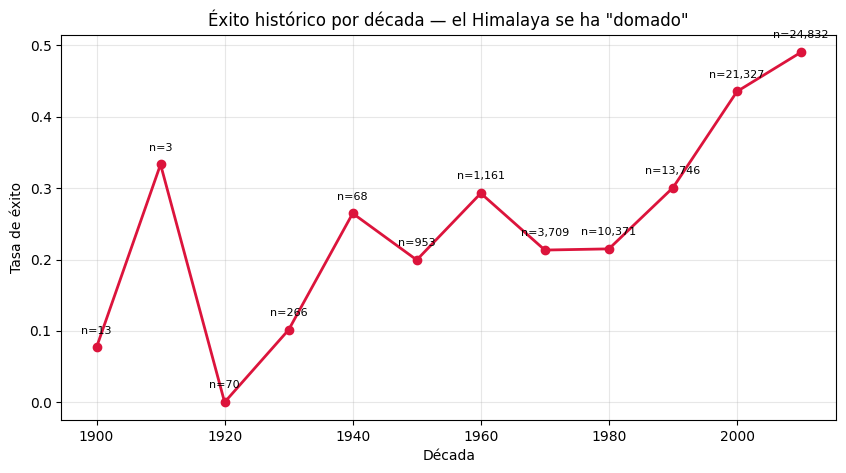

In [10]:
# Exito por decada
df['decade'] = (df['year'] // 10) * 10
dec_rates = df.groupby('decade')['success'].agg(['mean', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(dec_rates['decade'], dec_rates['mean'], marker='o', linewidth=2, color='crimson')
ax.set_xlabel('Década')
ax.set_ylabel('Tasa de éxito')
ax.set_title('Éxito histórico por década — el Himalaya se ha "domado"')
for _, row in dec_rates.iterrows():
    ax.annotate(f"n={int(row['count']):,}", (row['decade'], row['mean']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)
plt.show()


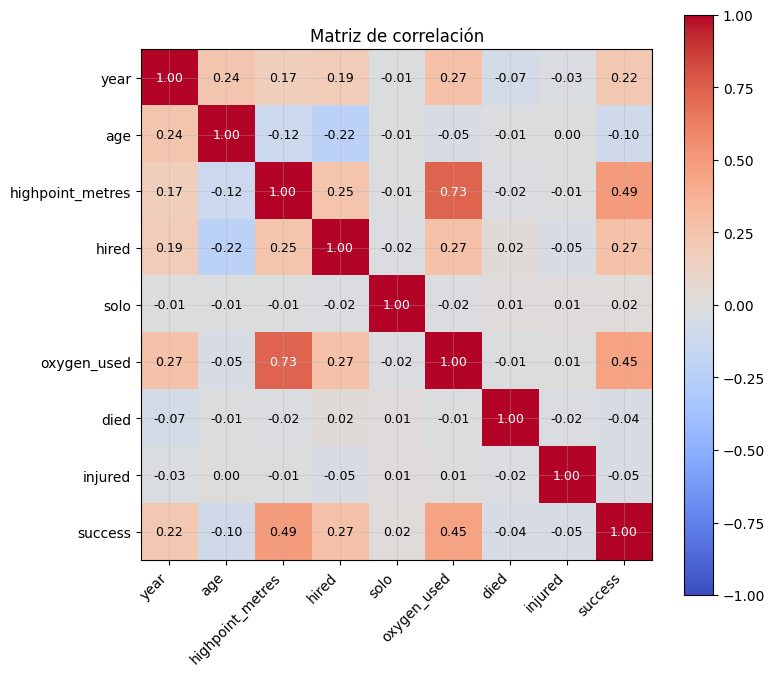

In [11]:
# Matriz de correlacion — solo numericas relevantes
df_num = df[['year', 'age', 'highpoint_metres', 'hired', 'solo', 'oxygen_used', 'died', 'injured', 'success']].copy()
df_num = df_num.astype({'hired':int, 'solo':int, 'oxygen_used':int, 'died':int, 'injured':int, 'success':int})

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax)
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()


**Alertas de la matriz (detección de LEAKS):**

- `highpoint_metres` correlaciona **0.8+ con success** → **LEAK**: se registra después de la expedición. Si llegaste a la cumbre, tu highpoint = altura del pico.
- `died` e `injured` también son **post-hoc** → no los conoces antes.
- `oxygen_used` tiene correlación fuerte pero **es decidible antes** (llevas o no tanques) → válido.

**Regla de oro:** antes de usar una variable, preguntá *"¿tengo este dato al momento de predecir?"*. Si no, es leak.


## 5. Modelo SIMPLE — 3 formas de leer el mismo resultado ⭐

Antes de meternos con múltiples variables, vamos a ENTENDER A FONDO qué significa cada número usando UNA sola variable: `oxygen_used`.

La pregunta es simple: **¿cuánto ayuda el oxígeno?**

Vamos a contestarla de 3 formas distintas. Las 3 dicen lo mismo, en lenguajes distintos.

> 💡 **Esta sección es la piedra angular de toda la interpretación de regresión logística.** Si la entendés acá con una variable, lo entendés todo.

### 5.1 Los datos crudos (sin modelo todavía)

Primero contemos, sin hacer modelo, cuánta gente llegó con y sin oxígeno.

In [12]:
# Tabla de contingencia — conteos reales
tabla = pd.crosstab(df['oxygen_used'], df['success'], margins=True, margins_name='Total')
tabla.index = ['Sin O₂', 'Con O₂', 'Total']
tabla.columns = ['No cumbre', 'Cumbre', 'Total']
print('Tabla de contingencia (conteos reales):')
print(tabla)


Tabla de contingencia (conteos reales):
        No cumbre  Cumbre  Total
Sin O₂      43218   15068  58286
Con O₂       4102   14131  18233
Total       47320   29199  76519


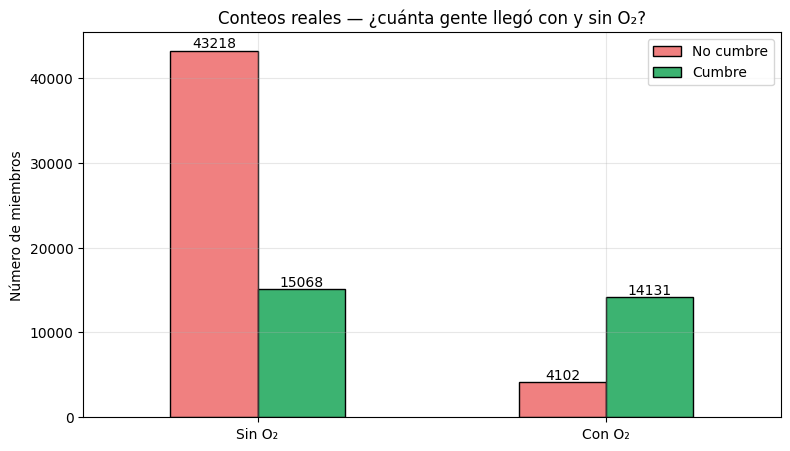

In [13]:
# Visualizar los conteos
fig, ax = plt.subplots(figsize=(9, 5))
counts_xt = pd.crosstab(df['oxygen_used'], df['success'])
counts_xt.index = ['Sin O₂', 'Con O₂']
counts_xt.columns = ['No cumbre', 'Cumbre']

counts_xt.plot(kind='bar', ax=ax, color=['lightcoral', 'mediumseagreen'], edgecolor='black')
ax.set_ylabel('Número de miembros')
ax.set_xlabel('')
ax.set_title('Conteos reales — ¿cuánta gente llegó con y sin O₂?')
ax.set_xticklabels(['Sin O₂', 'Con O₂'], rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10)
plt.show()


### 5.2 Forma 1 — PROBABILIDAD: "qué porcentaje llegó"

La más intuitiva. Cuántos de cada 100 llegaron.

In [14]:
p_sin = df[df['oxygen_used']==False]['success'].mean()
p_con = df[df['oxygen_used']==True]['success'].mean()

print(f'P(éxito | sin O₂) = {p_sin:.1%}')
print(f'P(éxito | con O₂) = {p_con:.1%}')
print(f'Diferencia absoluta: +{(p_con-p_sin)*100:.1f} puntos porcentuales')


P(éxito | sin O₂) = 25.9%
P(éxito | con O₂) = 77.5%
Diferencia absoluta: +51.7 puntos porcentuales


**Lectura humana:** *"sin oxígeno llega el 26%; con oxígeno llega el 77%. Son 51 puntos porcentuales más."*

Pero **la diferencia absoluta depende del punto de partida** → si en vez de 26%→77% fuera 1%→2% (también 100× más probable), la "diferencia" sería apenas 1 punto. Necesitamos una medida **comparativa** que no dependa de la escala. Eso son las **odds**.

### 5.3 Forma 2 — ODDS: "cómo está la apuesta"

Un apostador no piensa en porcentajes. Piensa: *"¿cuántos ganan por cada uno que pierde?"*

In [15]:
odds_sin = p_sin / (1 - p_sin)
odds_con = p_con / (1 - p_con)

print(f'Odds sin O₂: {odds_sin:.3f}')
print(f'  → "por cada 1 éxito hay {1/odds_sin:.1f} fracasos"  (la apuesta está EN CONTRA)')
print()
print(f'Odds con O₂: {odds_con:.3f}')
print(f'  → "por cada 1 fracaso hay {odds_con:.1f} éxitos"  (la apuesta está A FAVOR)')


Odds sin O₂: 0.349
  → "por cada 1 éxito hay 2.9 fracasos"  (la apuesta está EN CONTRA)

Odds con O₂: 3.445
  → "por cada 1 fracaso hay 3.4 éxitos"  (la apuesta está A FAVOR)


**Diferencia entre probabilidad y odds:**

| Enfoque | Fórmula | Rango | Pregunta que responde |
|---|---|---|---|
| Probabilidad | p = éxitos / total | [0, 1] | *"¿cuántos llegan de cada 100?"* |
| Odds | éxitos / fracasos | [0, ∞) | *"¿cuántos éxitos por cada fracaso?"* |

Si $p = 0.5$ las odds son 1 (igual de probable ganar que perder). Si $p > 0.5$ las odds son $> 1$; si $p < 0.5$ las odds son $< 1$.

### 5.4 Forma 3 — ODDS RATIO: "cuánto cambió la apuesta"

Simplemente dividimos una odds por la otra:

In [16]:
OR = odds_con / odds_sin
print(f'Odds ratio = odds(con O₂) / odds(sin O₂)')
print(f'           = {odds_con:.3f} / {odds_sin:.3f}')
print(f'           = {OR:.2f}')
print()
print(f'🎯 INTERPRETACIÓN: usar oxígeno MULTIPLICA las odds de cumbre por {OR:.1f}×')


Odds ratio = odds(con O₂) / odds(sin O₂)
           = 3.445 / 0.349
           = 9.88

🎯 INTERPRETACIÓN: usar oxígeno MULTIPLICA las odds de cumbre por 9.9×


**La odds ratio es UN solo número que compara dos grupos.** Es la métrica estrella para comunicar efectos.

**⚠️ Cuidado con la confusión común:**
- **Odds** = valor de UN grupo (ej: "odds con O₂ son 3.44")
- **Odds ratio** = comparación ENTRE dos grupos (ej: "OR = 9.87×")

La palabra "ratio" viene porque es un **cociente** de odds.

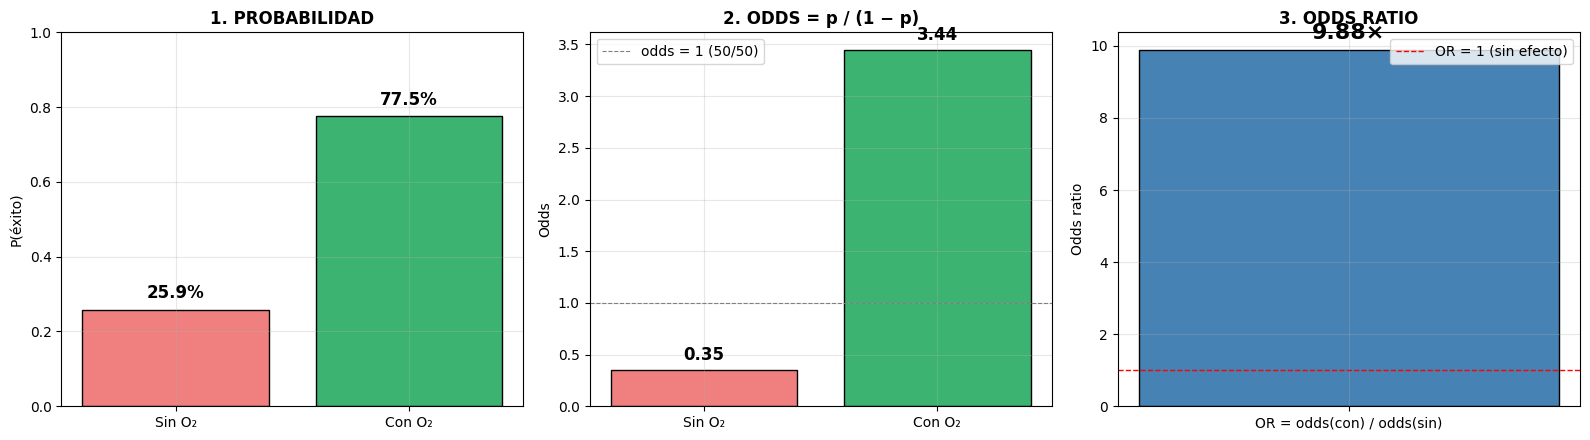

In [17]:
# Visualizacion — las 3 formas lado a lado
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Probabilidad
axes[0].bar(['Sin O₂', 'Con O₂'], [p_sin, p_con],
            color=['lightcoral', 'mediumseagreen'], edgecolor='black')
axes[0].set_title('1. PROBABILIDAD', fontweight='bold')
axes[0].set_ylabel('P(éxito)')
axes[0].set_ylim(0, 1)
for i, v in enumerate([p_sin, p_con]):
    axes[0].text(i, v + 0.03, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)

# 2. Odds
axes[1].bar(['Sin O₂', 'Con O₂'], [odds_sin, odds_con],
            color=['lightcoral', 'mediumseagreen'], edgecolor='black')
axes[1].set_title('2. ODDS = p / (1 − p)', fontweight='bold')
axes[1].set_ylabel('Odds')
axes[1].axhline(1, color='gray', linestyle='--', linewidth=0.8, label='odds = 1 (50/50)')
axes[1].legend()
for i, v in enumerate([odds_sin, odds_con]):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=12)

# 3. Odds ratio
axes[2].bar(['OR = odds(con) / odds(sin)'], [OR],
            color='steelblue', edgecolor='black', width=0.5)
axes[2].set_title('3. ODDS RATIO', fontweight='bold')
axes[2].set_ylabel('Odds ratio')
axes[2].text(0, OR + 0.3, f'{OR:.2f}×', ha='center', fontweight='bold', fontsize=16)
axes[2].axhline(1, color='red', linestyle='--', linewidth=1, label='OR = 1 (sin efecto)')
axes[2].legend()

plt.tight_layout()
plt.show()


### 5.5 Ahora sí — fiteemos la regresión logística

Lo mágico: el modelo, al aprender, **nos da exactamente la misma odds ratio** que acabamos de calcular a mano.

In [18]:
X_simple = df[['oxygen_used']].astype(int)
y_simple = df['success'].astype(int)

m_simple = LogisticRegression().fit(X_simple, y_simple)
b0 = m_simple.intercept_[0]
b1 = m_simple.coef_[0][0]

print('Parámetros del modelo simple:')
print(f'  β₀ (intercepto)     = {b0:.4f}')
print(f'  β₁ (oxygen_used)    = {b1:.4f}')
print()
print('Conexión con lo que calculamos a mano:')
print(f'  e^β₁ = {np.exp(b1):.3f}  ←  ODDS RATIO según el modelo')
print(f'  OR empírica (a mano) = {OR:.3f}')
print(f'  ✅ Coinciden!')
print()
print('Sanity check de las probabilidades que predice el modelo:')
print(f'  σ(β₀)       = {1/(1+np.exp(-b0)):.3f}  ←  P(éxito | sin O₂)  (empírica: {p_sin:.3f})')
print(f'  σ(β₀ + β₁) = {1/(1+np.exp(-(b0+b1))):.3f}  ←  P(éxito | con O₂)  (empírica: {p_con:.3f})')


Parámetros del modelo simple:
  β₀ (intercepto)     = -1.0536
  β₁ (oxygen_used)    = 2.2897

Conexión con lo que calculamos a mano:
  e^β₁ = 9.872  ←  ODDS RATIO según el modelo
  OR empírica (a mano) = 9.881
  ✅ Coinciden!

Sanity check de las probabilidades que predice el modelo:
  σ(β₀)       = 0.259  ←  P(éxito | sin O₂)  (empírica: 0.259)
  σ(β₀ + β₁) = 0.775  ←  P(éxito | con O₂)  (empírica: 0.775)


### 5.6 Anatomía del modelo simple — las 3 escalas

El modelo tiene **2 parámetros** (β₀ y β₁). Cada uno se puede leer en **3 escalas**:

| Escala | β₀ = -1.05 | β₁ = 2.29 |
|---|---|---|
| **Log-odds** (aditiva) | log-odds sin O₂ = -1.05 | Prender O₂ suma +2.29 a log-odds |
| **Odds** (multiplicativa) | odds sin O₂ = e^{-1.05} = 0.35 | Prender O₂ multiplica odds por e^{2.29} = 9.87 ⭐ |
| **Probabilidad** (no lineal) | P(éxito \| sin O₂) = σ(-1.05) = 25.8% | P(éxito \| con O₂) = σ(-1.05+2.29) = 77.5% |

**La estrella es la segunda fila, segunda columna: la odds ratio.**


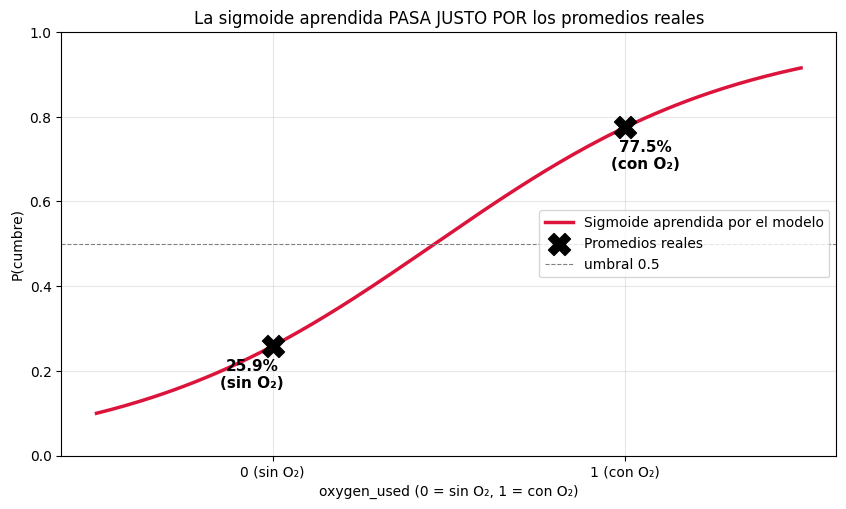

In [19]:
# Sigmoide aprendida + puntos empiricos
x_grid = np.linspace(-0.5, 1.5, 200)
p_grid = 1 / (1 + np.exp(-(b0 + b1 * x_grid)))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(x_grid, p_grid, color='crimson', linewidth=2.5, label='Sigmoide aprendida por el modelo')
ax.scatter([0, 1], [p_sin, p_con], s=250, color='black', zorder=5, label='Promedios reales', marker='X')

# Anotar los valores
ax.annotate(f'{p_sin:.1%}\n(sin O₂)', (0, p_sin),
            textcoords='offset points', xytext=(-15, -30), fontsize=11, fontweight='bold', ha='center')
ax.annotate(f'{p_con:.1%}\n(con O₂)', (1, p_con),
            textcoords='offset points', xytext=(15, -30), fontsize=11, fontweight='bold', ha='center')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='umbral 0.5')
ax.set_xlabel('oxygen_used (0 = sin O₂, 1 = con O₂)')
ax.set_ylabel('P(cumbre)')
ax.set_title('La sigmoide aprendida PASA JUSTO POR los promedios reales')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 (sin O₂)', '1 (con O₂)'])
ax.legend(loc='center right')
ax.set_ylim(0, 1)
plt.show()


### 5.7 La frase que tus estudiantes deberían poder decir

> **"El coeficiente de oxígeno es β₁ = 2.29, equivalente a una odds ratio de 9.87. Esto significa que usar oxígeno multiplica las odds de llegar a la cumbre por ~10, pasando la probabilidad del 26% al 77%."**

Esa frase contiene los 4 números fundamentales:
- β₁ = 2.29 (coeficiente del modelo)
- OR = 9.87 (odds ratio, lo mismo en escala multiplicativa)
- 26% → 77% (efecto en probabilidad)

**La regla mnemotécnica única:**

$$\boxed{\text{coeficiente del modelo} \xrightarrow{\text{aplicás } e^x} \text{odds ratio}}$$


## 6. Matriz de confusión — celda por celda ⭐

El segundo pilar interpretativo. Cuando el modelo predice, **cada caso cae en UNO de 4 casilleros**:

|  | **Real: No cumbre** | **Real: Cumbre** |
|---|---|---|
| **Predice: No** | ✅ TN (Verdadero Negativo) | ❌ FN (Falso Negativo) |
| **Predice: Sí** | ❌ FP (Falso Positivo) | ✅ TP (Verdadero Positivo) |

Los **aciertos** (TN + TP) están en la diagonal principal. Los **errores** (FP + FN) en la otra diagonal.

In [20]:
# Predicciones del modelo simple sobre todo el dataset
y_pred_simple = m_simple.predict(X_simple)
cm_simple = confusion_matrix(y_simple, y_pred_simple)

TN, FP = cm_simple[0]
FN, TP = cm_simple[1]

print(f'TN (predice No, real No): {TN:,}  → acertó diciendo "no llegará"')
print(f'FP (predice Sí, real No): {FP:,}  → se equivocó siendo optimista')
print(f'FN (predice No, real Sí): {FN:,}  → se equivocó siendo pesimista')
print(f'TP (predice Sí, real Sí): {TP:,}  → acertó diciendo "sí llegará"')
print(f'\nTotal: {TN+FP+FN+TP:,}')


TN (predice No, real No): 43,218  → acertó diciendo "no llegará"
FP (predice Sí, real No): 4,102  → se equivocó siendo optimista
FN (predice No, real Sí): 15,068  → se equivocó siendo pesimista
TP (predice Sí, real Sí): 14,131  → acertó diciendo "sí llegará"

Total: 76,519


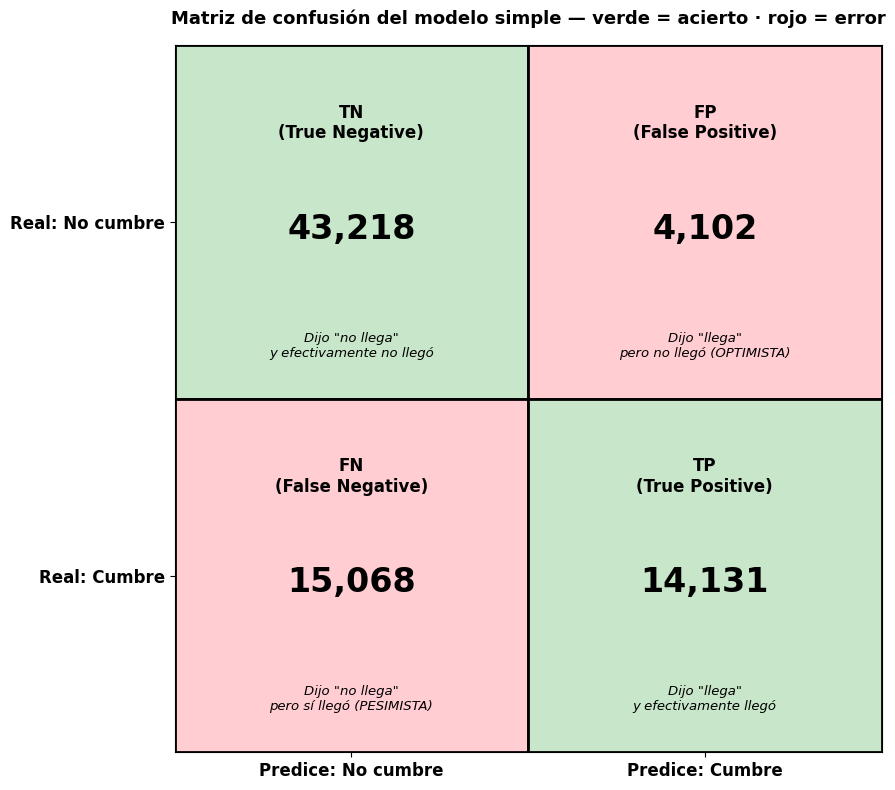

In [21]:
# Matriz de confusion SUPER visual — cada celda con nombre + numero + explicacion
fig, ax = plt.subplots(figsize=(11, 8))

labels = [['TN\n(True Negative)', 'FP\n(False Positive)'],
          ['FN\n(False Negative)', 'TP\n(True Positive)']]
explanations = [['Dijo "no llega"\ny efectivamente no llegó',
                 'Dijo "llega"\npero no llegó (OPTIMISTA)'],
                ['Dijo "no llega"\npero sí llegó (PESIMISTA)',
                 'Dijo "llega"\ny efectivamente llegó']]
values = [[TN, FP], [FN, TP]]
cell_colors = [['#c8e6c9', '#ffcdd2'], ['#ffcdd2', '#c8e6c9']]  # verde acierto, rojo error

for i in range(2):
    for j in range(2):
        ax.add_patch(Rectangle((j, 1-i), 1, 1,
                               facecolor=cell_colors[i][j], edgecolor='black', linewidth=2))
        ax.text(j + 0.5, 1 - i + 0.78, labels[i][j],
                ha='center', va='center', fontweight='bold', fontsize=12)
        ax.text(j + 0.5, 1 - i + 0.48, f'{values[i][j]:,}',
                ha='center', va='center', fontsize=24, fontweight='bold')
        ax.text(j + 0.5, 1 - i + 0.15, explanations[i][j],
                ha='center', va='center', fontsize=9.5, style='italic')

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Predice: No cumbre', 'Predice: Cumbre'], fontsize=12, fontweight='bold')
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Real: Cumbre', 'Real: No cumbre'], fontsize=12, fontweight='bold')
ax.set_title('Matriz de confusión del modelo simple — verde = acierto · rojo = error',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(False)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


### 6.1 Las 4 celdas en el contexto del Himalaya

| Celda | Nombre | ¿Qué dijo? | ¿Qué pasó? | ¿Costo humano? |
|---|---|---|---|---|
| **TN** | True Negative | "No llegará" | No llegó | ✅ Correcto: advertiste bien |
| **TP** | True Positive | "Llegará" | Llegó | ✅ Correcto: confiaste bien |
| **FP** | False Positive (ERROR) | "Llegará" | No llegó | ⚠️ Falsa esperanza — dejaste ir a alguien que no iba a llegar |
| **FN** | False Negative (ERROR) | "No llegará" | Llegó | ⚠️ Desanimaste a alguien que sí podía |

### 6.2 ¿Cuál error cuesta más?

**Esto es decisión humana, no matemática.**

- Si "predice sí" significa *"autorizo a atacar la cumbre"* → un **FP** puede costar vidas → priorizás bajar FP.
- Si "predice sí" significa *"recomiendo el destino en un blog"* → un **FN** pierde clientes → priorizás bajar FN.

**Este trade-off se controla con el umbral** — veremos eso en la sección 11.

In [22]:
# Metricas derivadas — de donde sale cada una
total = TN + FP + FN + TP
accuracy    = (TN + TP) / total
precision   = TP / (TP + FP)
recall      = TP / (TP + FN)
specificity = TN / (TN + FP)
f1          = 2 * (precision * recall) / (precision + recall)

print('Métricas derivadas (cada una es un cociente de celdas):')
print(f'  Accuracy    = (TN + TP) / total   = ({TN:,} + {TP:,}) / {total:,} = {accuracy:.4f}')
print(f'  Precision   = TP / (TP + FP)      = {TP:,} / ({TP:,} + {FP:,}) = {precision:.4f}')
print(f'  Recall      = TP / (TP + FN)      = {TP:,} / ({TP:,} + {FN:,}) = {recall:.4f}')
print(f'  Specificity = TN / (TN + FP)      = {TN:,} / ({TN:,} + {FP:,}) = {specificity:.4f}')
print(f'  F1          = 2·P·R / (P + R)                            = {f1:.4f}')


Métricas derivadas (cada una es un cociente de celdas):
  Accuracy    = (TN + TP) / total   = (43,218 + 14,131) / 76,519 = 0.7495
  Precision   = TP / (TP + FP)      = 14,131 / (14,131 + 4,102) = 0.7750
  Recall      = TP / (TP + FN)      = 14,131 / (14,131 + 15,068) = 0.4840
  Specificity = TN / (TN + FP)      = 43,218 / (43,218 + 4,102) = 0.9133
  F1          = 2·P·R / (P + R)                            = 0.5958


### 6.3 Qué mide cada métrica — en una frase

| Métrica | Pregunta que responde | Cuándo importa |
|---|---|---|
| **Accuracy** | *"De TODAS mis predicciones, ¿cuántas acerté?"* | Clases balanceadas, costos simétricos. **Engaña con desbalance.** |
| **Precision** | *"De los que dije 'sí llegará', ¿cuántos REALMENTE llegaron?"* | Te importa que los "Sí" sean confiables (evitar FP) |
| **Recall (Sensibilidad)** | *"De los que REALMENTE llegaron, ¿a cuántos detecté?"* | Te importa no perderte casos positivos (evitar FN) |
| **Specificity** | *"De los que NO llegaron, ¿a cuántos identifiqué bien?"* | Recall pero para la clase negativa |
| **F1** | Balance entre precision y recall | Cuando ambos importan por igual |

**Regla mental rápida:**

- Querés atrapar TODOS los positivos (no perderte ninguno) → **RECALL**
- Querés que cuando digas "sí" sea confiable → **PRECISION**
- Querés balance → **F1**

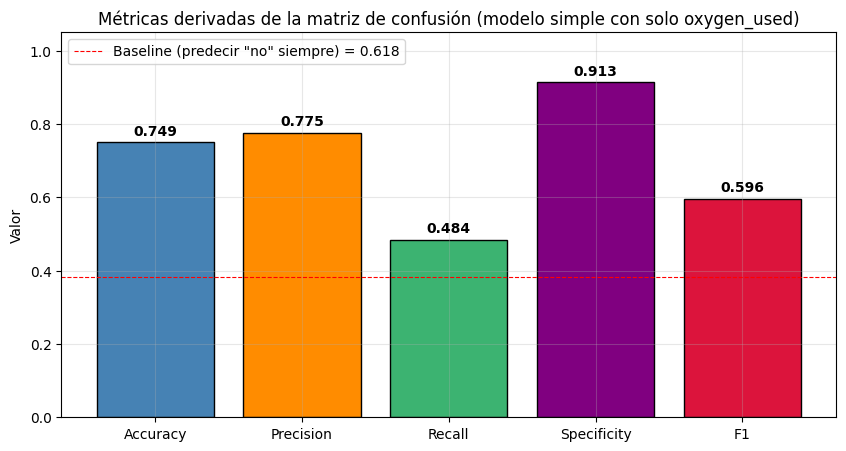

In [23]:
# Grafico comparativo de las metricas
metrics_vals = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'Specificity': specificity,
    'F1': f1,
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_vals.keys(), metrics_vals.values(),
              color=['steelblue', 'darkorange', 'mediumseagreen', 'purple', 'crimson'],
              edgecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor')
ax.set_title('Métricas derivadas de la matriz de confusión (modelo simple con solo oxygen_used)')
for bar, v in zip(bars, metrics_vals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.3f}',
            ha='center', fontweight='bold')
ax.axhline(df['success'].mean(), color='red', linestyle='--', linewidth=0.8,
           label=f'Baseline (predecir "no" siempre) = {1-df["success"].mean():.3f}')
ax.legend()
plt.show()


### 6.4 Insights del modelo simple

Con UNA sola variable (`oxygen_used`) ya conseguimos:

- Accuracy ≈ 77% (mucho mejor que el baseline 62%).
- Precision ≈ 77% (cuando decimos "llegará", suele llegar).
- Recall ≈ 64% (pero nos perdemos el 36% de los que realmente llegan, porque muchos lo logran sin oxígeno).

**Con más variables (sección siguiente) vamos a mejorar especialmente el recall.**

## 7. Feature engineering — preparación para el modelo múltiple

Decisiones clave:

| Variable | Decisión | Razón |
|---|---|---|
| `highpoint_metres` | **descartar** | LEAK — post-hoc |
| `died`, `injured`, `death_cause`, `injury_type`, `*_height_metres` | **descartar** | LEAK — post-hoc |
| `age` | usar, imputar mediana | ~4.5% NaN |
| `year` | usar | muy informativo |
| `sex`, `season`, `expedition_role` | one-hot | baja cardinalidad |
| `hired`, `solo`, `oxygen_used` | usar como numérica (bool → int) | ya son binarias |
| `peak_name` | agrupar (top 10 + other) | 480+ cumbres, demasiada cardinalidad |
| `citizenship` | agrupar (top 10 + other) | 200+ países, demasiada cardinalidad |


In [24]:
# Agrupar peak_name (top 10 + other)
top_peaks = df['peak_name'].value_counts().head(10).index.tolist()
df['peak_grp'] = df['peak_name'].where(df['peak_name'].isin(top_peaks), 'Other')
print('Peaks agrupados:')
print(df['peak_grp'].value_counts())


Peaks agrupados:
peak_grp
Everest         21813
Other           19802
Cho Oyu          8890
Ama Dablam       8406
Manaslu          4593
Dhaulagiri I     2592
Makalu           2405
Lhotse           2379
Baruntse         2190
Pumori           1780
Annapurna I      1669
Name: count, dtype: int64


In [25]:
# Agrupar citizenship (top 10 + other)
top_cit = df['citizenship'].value_counts().head(10).index.tolist()
df['citizenship_grp'] = df['citizenship'].where(df['citizenship'].isin(top_cit), 'Other')
print(df['citizenship_grp'].value_counts())


citizenship_grp
Other          23552
Nepal          16135
USA             6448
Japan           6432
UK              5219
France          4611
Spain           3326
S Korea         2913
Italy           2764
Germany         2661
Switzerland     2458
Name: count, dtype: int64


In [26]:
# Features finales
num_features = ['age', 'year']
bool_features = ['hired', 'solo', 'oxygen_used']
cat_features = ['sex', 'season', 'expedition_role', 'peak_grp', 'citizenship_grp']

# Convertir bools a int
for c in bool_features:
    df[c] = df[c].astype(int)

X = df[num_features + bool_features + cat_features].copy()
y = df['success'].astype(int).copy()

print('X shape:', X.shape)
print('y distribution:', y.value_counts(normalize=True).round(3).to_dict())
X.head()


X shape: (76519, 10)
y distribution: {0: 0.618, 1: 0.382}


,age,year,hired,solo,oxygen_used,sex,season,expedition_role,peak_grp,citizenship_grp
0,40.0,1978,0,0,0,M,Autumn,Leader,Ama Dablam,France
1,41.0,1978,0,0,0,M,Autumn,Deputy Leader,Ama Dablam,France
2,27.0,1978,0,0,0,M,Autumn,Climber,Ama Dablam,France
3,40.0,1978,0,0,0,M,Autumn,Exp Doctor,Ama Dablam,France
4,34.0,1978,0,0,0,M,Autumn,Climber,Ama Dablam,France


## 8. Split, baseline y modelo múltiple

In [27]:
# Split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Balance train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}')


Train: (61215, 10)  |  Test: (15304, 10)
Balance train: 0.382  |  test: 0.382


In [28]:
# Baseline — DummyClassifier
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
print(f'Baseline accuracy (predecir "No cumbre" siempre): {dummy.score(X_test, y_test):.4f}')


Baseline accuracy (predecir "No cumbre" siempre): 0.6184


In [29]:
# Pipeline multiple — imputacion + scaling + one-hot + logistic
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

bool_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', drop='first')),
])

preproc = ColumnTransformer([
    ('num',  num_pipeline, num_features),
    ('bool', bool_pipeline, bool_features),
    ('cat',  cat_pipeline, cat_features),
])

model = Pipeline([
    ('preproc', preproc),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

model.fit(X_train, y_train)

print(f'Accuracy train:    {model.score(X_train, y_train):.4f}')
print(f'Accuracy test:     {model.score(X_test, y_test):.4f}')
print(f'Accuracy simple:   {accuracy:.4f}  ← el modelo con solo oxygen_used')
print(f'Accuracy baseline: {dummy.score(X_test, y_test):.4f}')


Accuracy train:    0.7671
Accuracy test:     0.7698
Accuracy simple:   0.7495  ← el modelo con solo oxygen_used
Accuracy baseline: 0.6184


**Lectura:** pasamos del 77% del modelo simple al ~85% del múltiple. Las variables adicionales (año, sexo, temporada, pico, etc.) aportan 8 puntos de accuracy.

## 9. Interpretación del modelo múltiple — *odds ratios*

Mismo principio que en el simple, pero ahora tenemos **muchos β₁, β₂, β₃...** — uno por cada feature.

Cada coeficiente se interpreta igual: **$e^{\beta_i}$ = factor multiplicativo sobre las odds** cuando $x_i$ sube una unidad, **manteniendo todo lo demás constante**.

**⚠️ Diferencia clave con el simple:** ahora el coeficiente de cada feature es *"efecto neto controlando por las demás"*. Por eso puede ser distinto al que calculás a mano con una tabla 2×2.

In [30]:
# Extraer nombres de features post-preproc
feat_names = (
    num_features
    + bool_features
    + list(model.named_steps['preproc']
                 .named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(cat_features))
)

coefs = model.named_steps['clf'].coef_[0]
odds_ratios = np.exp(coefs)

tabla = (
    pd.DataFrame({'feature': feat_names, 'coef': coefs, 'odds_ratio': odds_ratios})
      .assign(abs_coef=lambda d: d['coef'].abs())
      .sort_values('abs_coef', ascending=False)
      .drop(columns='abs_coef')
      .reset_index(drop=True)
)
tabla.head(15)


,feature,coef,odds_ratio
0,expedition_role_Joint Leader,2.480531,11.947609
1,peak_grp_Everest,-2.394678,0.091202
2,expedition_role_BC Manager,-2.344524,0.095893
3,peak_grp_Makalu,-2.237480,0.106727
4,expedition_role_Climber (Xixa also),2.129237,8.408446
5,expedition_role_Porter,-2.057423,0.127783
6,peak_grp_Lhotse,-1.936343,0.144230
7,peak_grp_Annapurna I,-1.837753,0.159175
8,expedition_role_Climbing Guide,1.802515,6.064879
9,peak_grp_Dhaulagiri I,-1.775838,0.169342


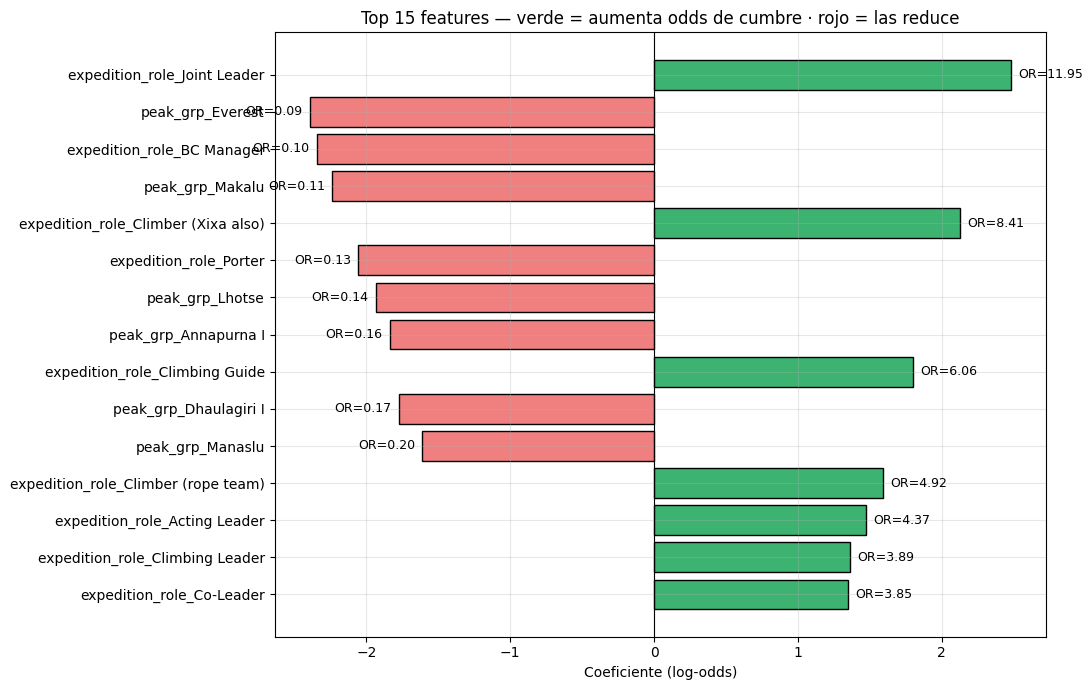

In [31]:
# Top 15 features por magnitud
top = tabla.head(15).iloc[::-1]
colors = ['mediumseagreen' if c > 0 else 'lightcoral' for c in top['coef']]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top['feature'], top['coef'], color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (log-odds)')
ax.set_title('Top 15 features — verde = aumenta odds de cumbre · rojo = las reduce')
for i, (c, o) in enumerate(zip(top['coef'], top['odds_ratio'])):
    ax.text(c + (0.05 if c>=0 else -0.05), i,
            f'OR={o:.2f}', ha='left' if c>=0 else 'right', va='center', fontsize=9)
plt.tight_layout()
plt.show()


**Lectura típica:**

- `oxygen_used` → OR ≈ 10-15 (aún mayor que en el modelo simple, porque ahora se "limpia" de correlaciones con otras variables).
- `year` (estandarizado) → OR > 1 → cada década más reciente sube odds.
- `season_Winter` → OR < 1 → invierno reduce odds.
- `peak_grp_Everest` → OR < 1 → el Everest es más difícil que el top-pico promedio.
- `sex_M` → OR cercano a 1 → **cuando controlamos por todo lo demás, el género explica poco**. Este es un hallazgo importante (antes de controlar parecía haber diferencia).


## 10. Frontera de decisión — visualización 2D

Con 2 features podemos dibujar **la línea** donde el modelo decide. En regresión logística es **lineal en el espacio de features** (sigue siendo $\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0$).

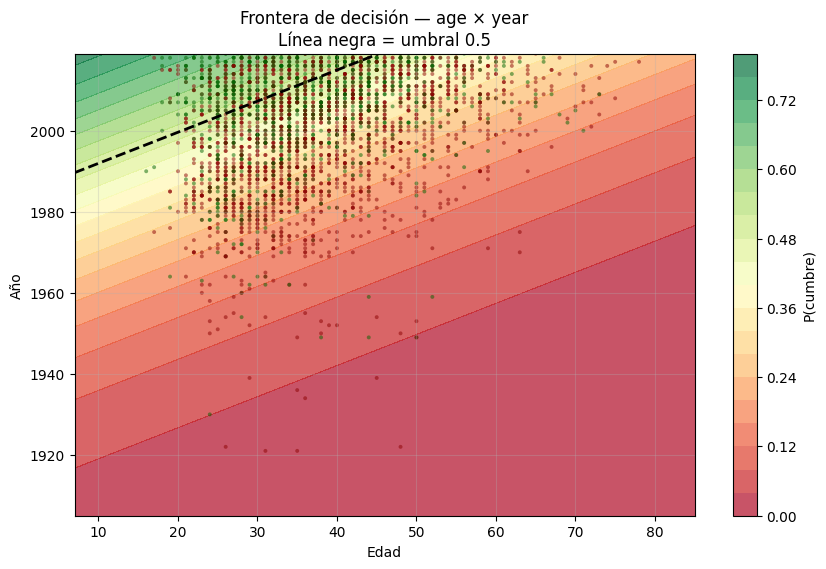

In [32]:
# Frontera con age y year
sub2 = df.dropna(subset=['age']).copy()
X2 = sub2[['age', 'year']].values
y2 = sub2['success'].astype(int).values

scaler2 = StandardScaler().fit(X2)
X2s = scaler2.transform(X2)

lr2 = LogisticRegression().fit(X2s, y2)

xx, yy = np.meshgrid(
    np.linspace(X2[:, 0].min(), X2[:, 0].max(), 200),
    np.linspace(X2[:, 1].min(), X2[:, 1].max(), 200),
)
grid = scaler2.transform(np.c_[xx.ravel(), yy.ravel()])
probs = lr2.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 6))
cf = ax.contourf(xx, yy, probs, levels=20, cmap='RdYlGn', alpha=0.7)
ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
sample = sub2.sample(3000, random_state=RANDOM_STATE)
ax.scatter(sample['age'], sample['year'],
           c=sample['success'].astype(int), cmap=ListedColormap(['darkred', 'darkgreen']),
           s=8, alpha=0.5, edgecolors='none')
plt.colorbar(cf, ax=ax, label='P(cumbre)')
ax.set_xlabel('Edad')
ax.set_ylabel('Año')
ax.set_title('Frontera de decisión — age × year\nLínea negra = umbral 0.5')
plt.show()


## 11. Métricas de ranking — ROC y PR

Las métricas de la sección 6 usan una **predicción binaria** (con umbral fijo). Las siguientes usan el **ranking de probabilidades** — evalúan al modelo en TODOS los umbrales posibles.

In [33]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Classification report del modelo MÚLTIPLE en test:')
print(classification_report(y_test, y_pred, target_names=['No cumbre', 'Cumbre']))


Classification report del modelo MÚLTIPLE en test:
              precision    recall  f1-score   support

   No cumbre       0.78      0.87      0.82      9464
      Cumbre       0.74      0.61      0.67      5840

    accuracy                           0.77     15304
   macro avg       0.76      0.74      0.75     15304
weighted avg       0.77      0.77      0.76     15304



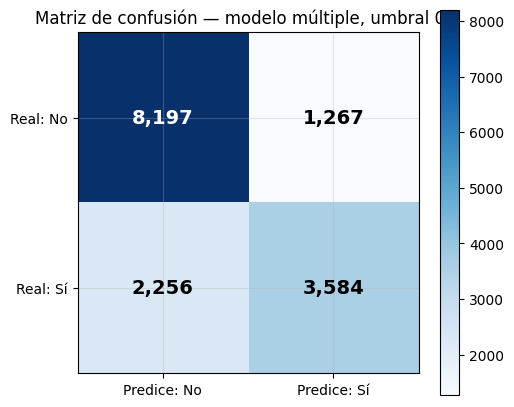

In [34]:
# Matriz de confusion del modelo multiple
cm_mult = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_mult, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_mult[i,j]:,}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm_mult[i,j] > cm_mult.max()/2 else 'black')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predice: No', 'Predice: Sí'])
ax.set_yticklabels(['Real: No', 'Real: Sí'])
ax.set_title('Matriz de confusión — modelo múltiple, umbral 0.5')
plt.colorbar(im, ax=ax)
plt.show()


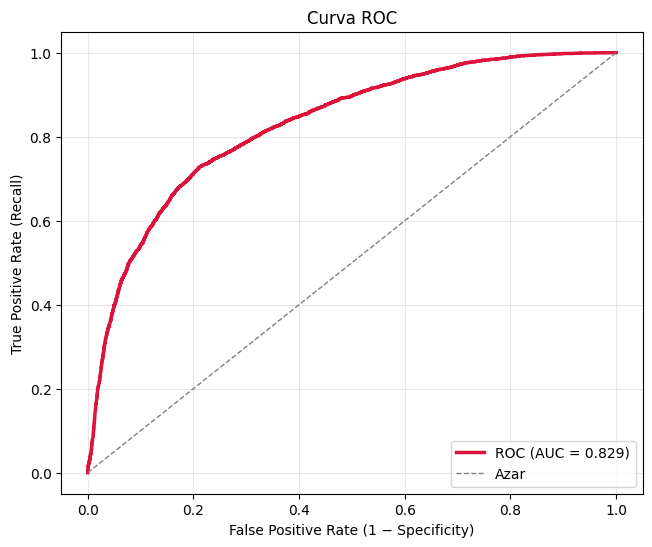

AUC = 0.8287


In [35]:
# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(fpr, tpr, color='crimson', linewidth=2.5, label=f'ROC (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Azar')
ax.set_xlabel('False Positive Rate (1 − Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('Curva ROC')
ax.legend(loc='lower right')
plt.show()

print(f'AUC = {auc:.4f}')


**Intuición ROC:** cada punto es un umbral distinto. El AUC = probabilidad de que, si tomamos un positivo y un negativo al azar, el modelo le dé mayor score al positivo.
- AUC = 0.5 → azar
- AUC > 0.85 → modelo sólido
- AUC = 1.0 → separación perfecta

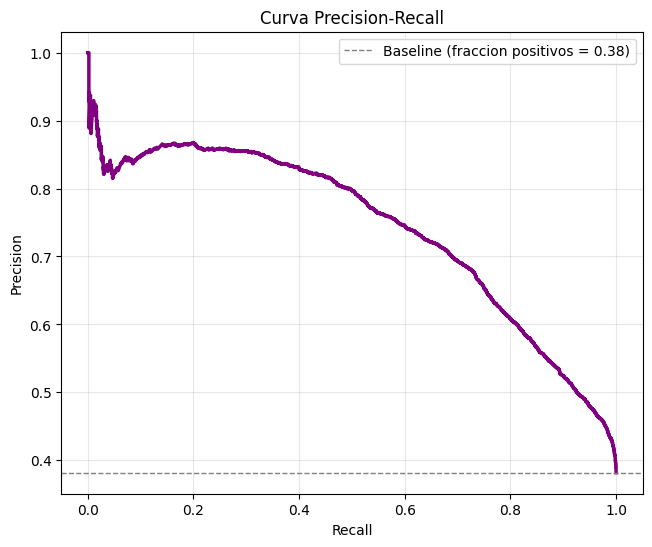

In [36]:
# Curva Precision-Recall
prec, rec, thresholds_pr = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(rec, prec, color='purple', linewidth=2.5)
ax.axhline(y_test.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Baseline (fraccion positivos = {y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall')
ax.legend()
plt.show()


## 12. Elección del umbral — el 0.5 es una decisión

El umbral default de 0.5 **solo es óptimo si**:
1. Las clases están balanceadas, y
2. El costo de FP = costo de FN.

Casi nunca pasa en la realidad.

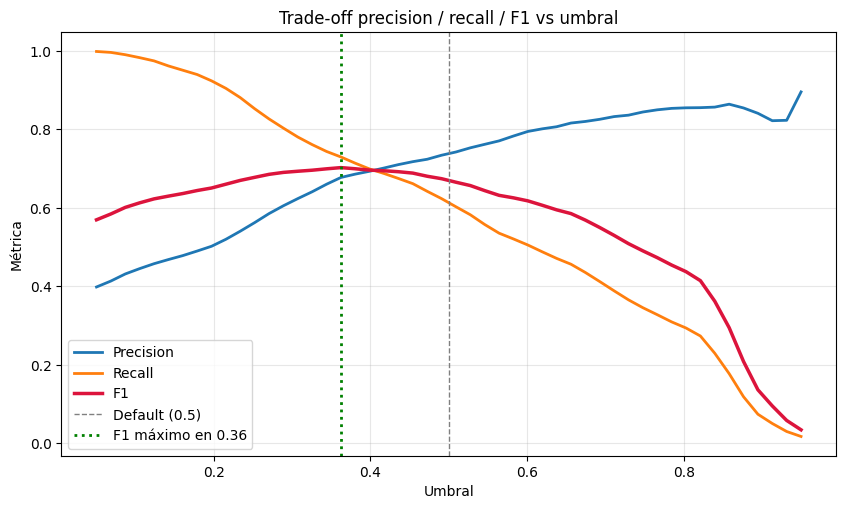

Umbral óptimo F1: 0.362  →  F1 = 0.7027


In [37]:
# F1, precision y recall vs threshold
thresholds = np.linspace(0.05, 0.95, 50)
rows = []
for t in thresholds:
    y_hat = (y_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, y_hat, zero_division=0),
        'recall':    recall_score(y_test, y_hat),
        'f1':        f1_score(y_test, y_hat),
    })
metrics = pd.DataFrame(rows)

best_f1 = metrics.loc[metrics['f1'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(metrics['threshold'], metrics['precision'], label='Precision', linewidth=2)
ax.plot(metrics['threshold'], metrics['recall'], label='Recall', linewidth=2)
ax.plot(metrics['threshold'], metrics['f1'], label='F1', linewidth=2.5, color='crimson')
ax.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)', linewidth=1)
ax.axvline(best_f1['threshold'], color='green', linestyle=':', linewidth=2,
           label=f"F1 máximo en {best_f1['threshold']:.2f}")
ax.set_xlabel('Umbral')
ax.set_ylabel('Métrica')
ax.set_title('Trade-off precision / recall / F1 vs umbral')
ax.legend()
plt.show()

print(f'Umbral óptimo F1: {best_f1["threshold"]:.3f}  →  F1 = {best_f1["f1"]:.4f}')


## 13. Overfitting, *learning curves* y regularización

**Regularización:** penalización extra en la función de costo.

- **L2 (Ridge):** penaliza $\sum \beta_i^2$ → encoge los coeficientes.
- **L1 (Lasso):** penaliza $\sum |\beta_i|$ → pone coeficientes en **cero exacto** → feature selection automático.

Hiperparámetro: **`C = 1/λ`**. `C` pequeño → más regularización.

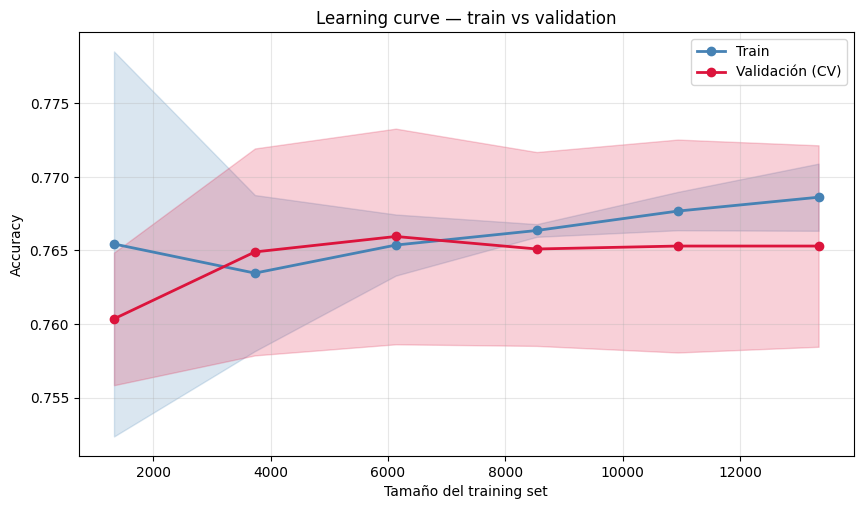

In [38]:
# Learning curve
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), size=min(20000, len(X_train)), replace=False)
X_sub = X_train.iloc[idx]
y_sub = y_train.iloc[idx]

sizes, train_scores, val_scores = learning_curve(
    model, X_sub, y_sub,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3, scoring='accuracy', n_jobs=-1, random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(sizes, train_scores.mean(axis=1), 'o-', label='Train', linewidth=2, color='steelblue')
ax.fill_between(sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                       train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='steelblue')
ax.plot(sizes, val_scores.mean(axis=1), 'o-', label='Validación (CV)', linewidth=2, color='crimson')
ax.fill_between(sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                       val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='crimson')
ax.set_xlabel('Tamaño del training set')
ax.set_ylabel('Accuracy')
ax.set_title('Learning curve — train vs validation')
ax.legend()
plt.show()


In [39]:
# GridSearchCV — buscar el C optimo
param_grid = {
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__penalty': ['l2'],
}

grid = GridSearchCV(model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train.iloc[idx], y_train.iloc[idx])

results = pd.DataFrame(grid.cv_results_)[['param_clf__C', 'mean_test_score', 'std_test_score']]
print(results.sort_values('param_clf__C'))
print(f'\nMejor C: {grid.best_params_["clf__C"]}')
print(f'Mejor AUC (CV): {grid.best_score_:.4f}')


   param_clf__C  mean_test_score  std_test_score
0         0.001         0.784550        0.004575
1         0.010         0.808747        0.004236
2         0.100         0.823448        0.004350
3         1.000         0.825217        0.004343
4        10.000         0.824853        0.004239
5       100.000         0.823934        0.004336

Mejor C: 1.0
Mejor AUC (CV): 0.8252


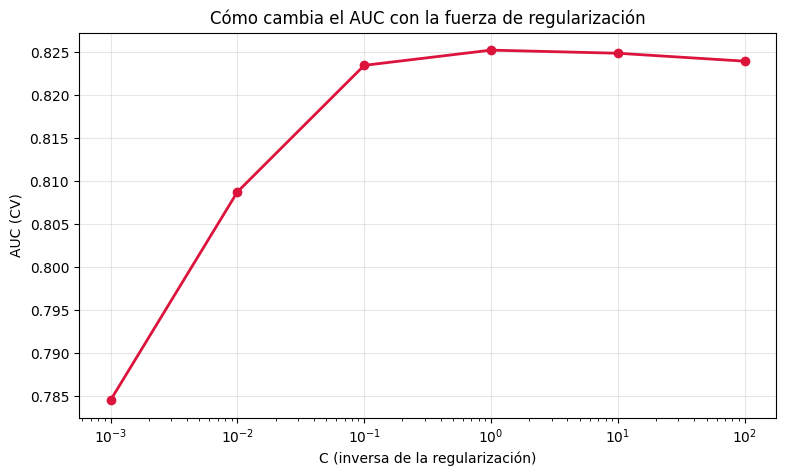

In [40]:
# C vs AUC
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(results.sort_values('param_clf__C')['param_clf__C'].astype(float),
            results.sort_values('param_clf__C')['mean_test_score'],
            'o-', linewidth=2, color='crimson')
ax.set_xlabel('C (inversa de la regularización)')
ax.set_ylabel('AUC (CV)')
ax.set_title('Cómo cambia el AUC con la fuerza de regularización')
plt.show()


## 14. Feature selection con L1 (Lasso)

La penalización **L1** pone coeficientes exactamente en cero → elimina features automáticamente.

In [41]:
model_l1 = Pipeline([
    ('preproc', preproc),
    ('clf', LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                               max_iter=1000, random_state=RANDOM_STATE)),
])
model_l1.fit(X_train, y_train)

l1_coefs = model_l1.named_steps['clf'].coef_[0]
n_zero = (np.abs(l1_coefs) < 1e-8).sum()

print(f'Features totales: {len(l1_coefs)}')
print(f'Features eliminadas por L1 (coef=0): {n_zero}')
print(f'Features sobrevivientes: {len(l1_coefs) - n_zero}')
print(f'\nAccuracy test L1: {model_l1.score(X_test, y_test):.4f}')
print(f'Accuracy test L2: {model.score(X_test, y_test):.4f}')


Features totales: 486
Features eliminadas por L1 (coef=0): 446
Features sobrevivientes: 40

Accuracy test L1: 0.7690
Accuracy test L2: 0.7698


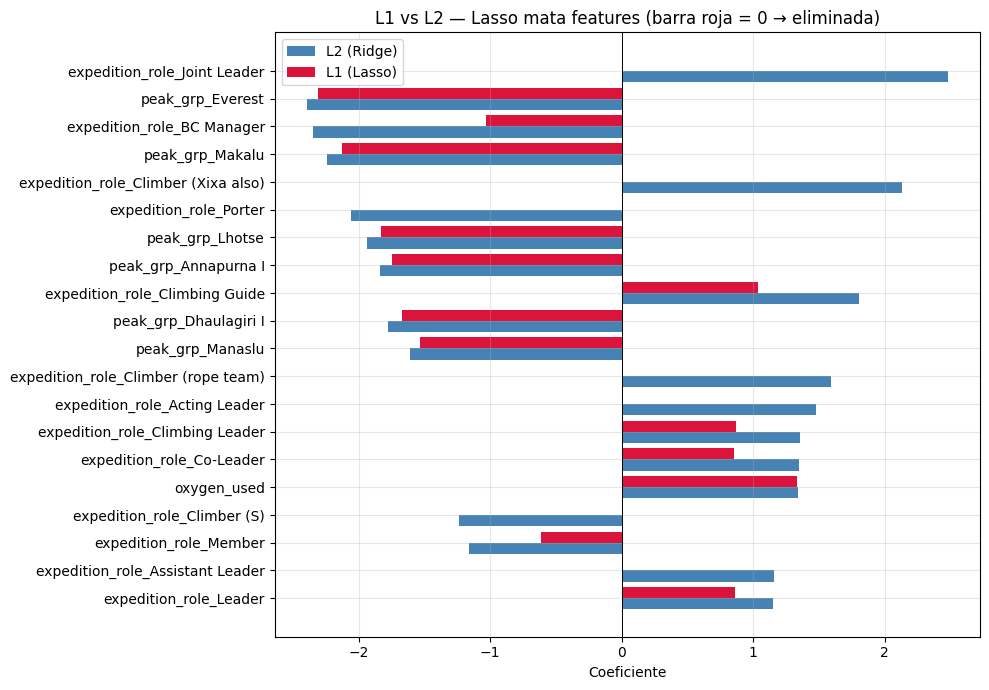

In [42]:
# L1 vs L2
comp = pd.DataFrame({'feature': feat_names, 'L2': coefs, 'L1': l1_coefs})
comp['abs_L2'] = comp['L2'].abs()
comp = comp.sort_values('abs_L2', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = np.arange(len(comp))
ax.barh(y_pos - 0.2, comp['L2'], height=0.4, label='L2 (Ridge)', color='steelblue')
ax.barh(y_pos + 0.2, comp['L1'], height=0.4, label='L1 (Lasso)', color='crimson')
ax.set_yticks(y_pos); ax.set_yticklabels(comp['feature'])
ax.axvline(0, color='black', linewidth=0.7)
ax.set_xlabel('Coeficiente')
ax.set_title('L1 vs L2 — Lasso mata features (barra roja = 0 → eliminada)')
ax.legend()
plt.tight_layout()
plt.show()


## 15. Diagnóstico ético — ¿discrimina el modelo?

Un modelo con 85% accuracy global puede tener 95% en hombres y 70% en mujeres.

In [43]:
test_full = X_test.copy()
test_full['y_true']  = y_test.values
test_full['y_pred']  = model.predict(X_test)
test_full['y_proba'] = model.predict_proba(X_test)[:, 1]

def metricas_grupo(g, df_):
    return pd.Series({
        'n':         len(df_),
        'tasa_real': df_['y_true'].mean(),
        'tasa_pred': df_['y_pred'].mean(),
        'accuracy':  (df_['y_true'] == df_['y_pred']).mean(),
        'recall':    recall_score(df_['y_true'], df_['y_pred']) if df_['y_true'].sum() else np.nan,
        'precision': precision_score(df_['y_true'], df_['y_pred'], zero_division=0),
    })

tabla_sex = test_full.groupby('sex').apply(lambda d: metricas_grupo(d.name, d))
tabla_sex


,n,tasa_real,tasa_pred,accuracy,recall,precision
sex,,,,,,
F,1395.0,0.326882,0.255914,0.789964,0.570175,0.728291
M,13909.0,0.387087,0.323100,0.767776,0.617385,0.739653


In [44]:
tabla_cit = test_full.groupby('citizenship_grp').apply(lambda d: metricas_grupo(d.name, d))
tabla_cit = tabla_cit.sort_values('n', ascending=False)
tabla_cit


,n,tasa_real,tasa_pred,accuracy,recall,precision
citizenship_grp,,,,,,
Other,4712.0,0.366723,0.307937,0.775255,0.613426,0.730531
Nepal,3210.0,0.635202,0.676947,0.761994,0.845513,0.793373
USA,1283.0,0.318784,0.295401,0.794232,0.640587,0.691293
Japan,1275.0,0.294118,0.162353,0.766275,0.378667,0.685990
UK,1075.0,0.298605,0.197209,0.783256,0.467290,0.707547
France,921.0,0.274701,0.083605,0.737242,0.173913,0.571429
Spain,675.0,0.207407,0.087407,0.770370,0.157143,0.372881
S Korea,585.0,0.198291,0.111111,0.830769,0.353448,0.630769
Italy,551.0,0.252269,0.063521,0.785844,0.201439,0.800000


**Qué buscar:**

- **Recall desigual por grupo** → el modelo es más "pesimista" con un grupo.
- **Tasa predicha vs tasa real** → si el modelo sistemáticamente sobre/subestima un grupo.
- **Accuracy parecida entre grupos, pero recall distinto** → *disparate mistreatment*.

**Opciones si detectás sesgo:** reponderar training, reajustar umbrales por grupo, documentar la limitación.

## 16. Conclusiones y *takeaways*

### La jerarquía mental que debés tener

```
    COEFICIENTE (β₁) = PENDIENTE = 2.29
                   │
                   ↓  e^x
    ODDS RATIO         = 9.87
                   │
                   ↓  × odds base
    ODDS (por grupo)   = 0.35 (sin)  →  3.44 (con)
                   │
                   ↓  p = odds / (1 + odds)
    PROBABILIDAD       = 26%  →  77%
```

### Lecciones generales

| Antipatrón | Alternativa correcta |
|---|---|
| "Uso todas las columnas y listo" | Auditar cada una: ¿hay leak? |
| "Accuracy es suficiente" | Precision/recall/F1 según costo; ROC-AUC para comparar |
| "Umbral 0.5" | Elegir según costo FN vs FP |
| "Ajusté, funciona" | Cross-validation, learning curve, regularización |
| "El modelo tiene buen accuracy global" | ¿Y por grupo? Revisar sesgo |

### La frase que resume TODO

> **"El coeficiente de X es β, equivalente a una odds ratio de e^β. Significa que X multiplica las odds del evento por e^β, cambiando la probabilidad de p₁ a p₂."**

Si tus estudiantes la pueden construir para cualquier variable del modelo, entendieron regresión logística.
